In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("=== DTYPES ===")
print(df.dtypes)

print("\n=== NULL COUNTS ===")
print(df.isnull().sum())

print("\n=== BASIC STATS ===")
df.describe()

=== DTYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== NULL COUNTS ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessB

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Check TotalCharges dtype
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")

# Find the blank strings
blank_mask = df['TotalCharges'].str.strip() == ''
print(f"Blank TotalCharges rows: {blank_mask.sum()}")

# Look at those rows
df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

TotalCharges dtype: object
Blank TotalCharges rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%
Retention Rate: 73.5%


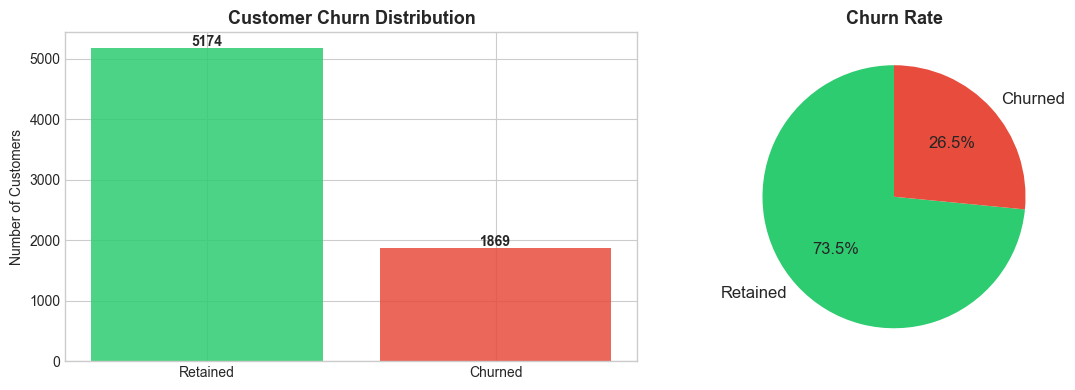

In [7]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print(f"Churn Distribution:\n{churn_counts}")
print(f"\nChurn Rate: {churn_rate['Yes']:.1f}%")
print(f"Retention Rate: {churn_rate['No']:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Retained', 'Churned'], churn_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.85)
axes[0].set_title('Customer Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

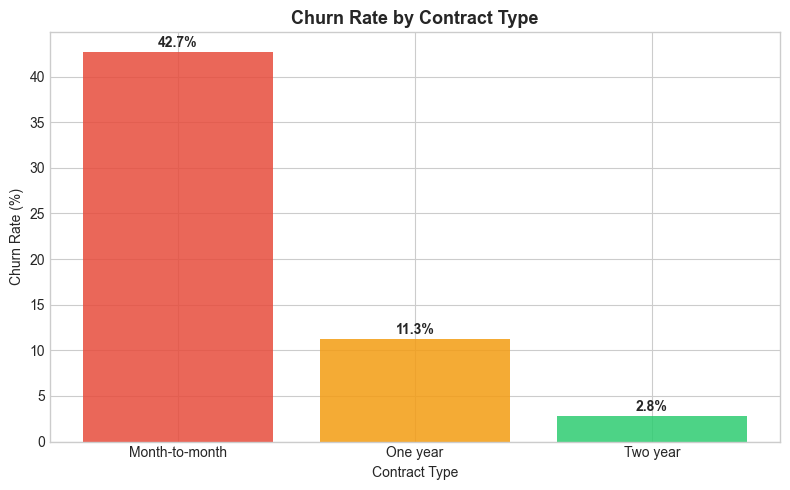

         Contract  Churn Rate (%)
0  Month-to-month       42.709677
1        One year       11.269518
2        Two year        2.831858


In [8]:
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']
contract_churn = contract_churn.sort_values('Churn Rate (%)', ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
               color=['#e74c3c', '#f39c12', '#2ecc71'], alpha=0.85)
plt.title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print(contract_churn)

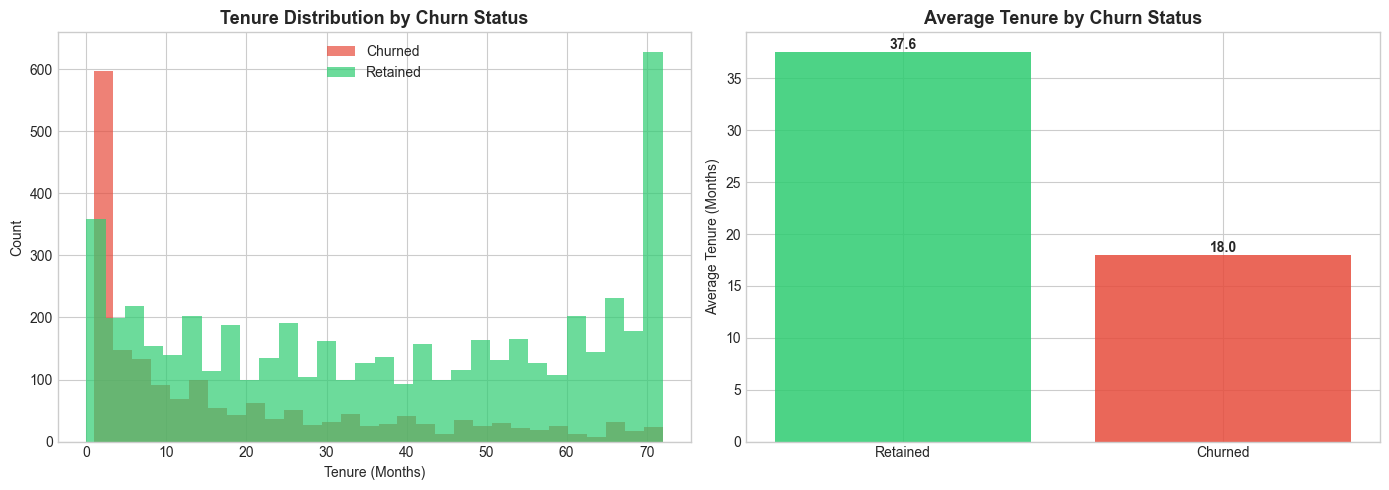

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, ax=axes[0], color='#e74c3c',
                                         alpha=0.7, label='Churned')
df[df['Churn'] == 'No']['tenure'].hist(bins=30, ax=axes[0], color='#2ecc71',
                                        alpha=0.7, label='Retained')
axes[0].set_title('Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Count')
axes[0].legend()

avg_tenure = df.groupby('Churn')['tenure'].mean()
axes[1].bar(['Retained', 'Churned'], avg_tenure.values,
            color=['#2ecc71', '#e74c3c'], alpha=0.85)
axes[1].set_title('Average Tenure by Churn Status', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Tenure (Months)')
for i, v in enumerate(avg_tenure.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'ax' is not defined

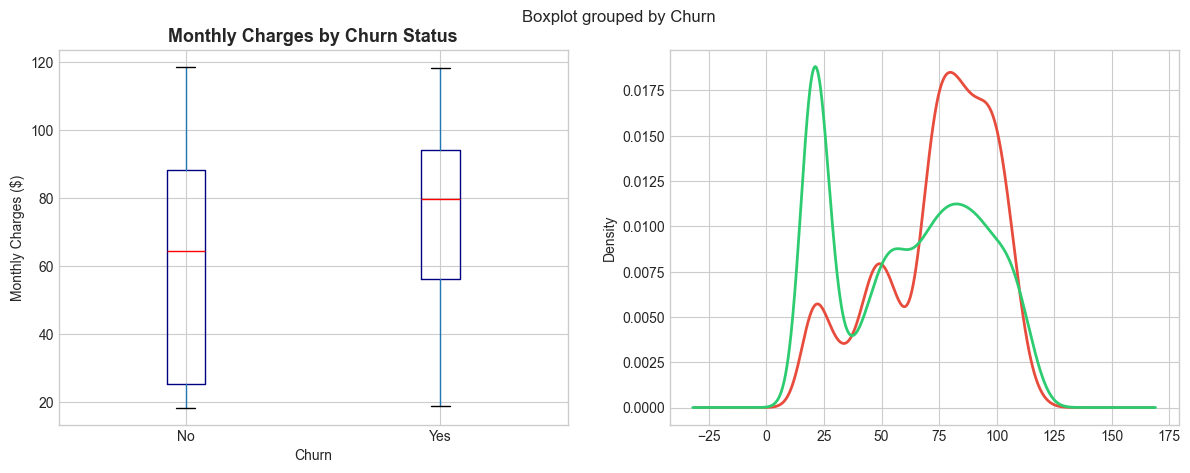

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0],
           boxprops=dict(color='navy'), medianprops=dict(color='red'))
axes[0].set_title('Monthly Charges by Churn Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')

df[df['Churn'] == 'Yes']['MonthlyCharges'].plot(kind='kde', ax=axes[1],
                                                  color='#e74c3c', label='Churned', linewidth=2)
df[df['Churn'] == 'No']['MonthlyCharges'].plot(kind='kde', ax=axes[1],
                                                color='#2ecc71', label='Retained', linewidth=2)
ax

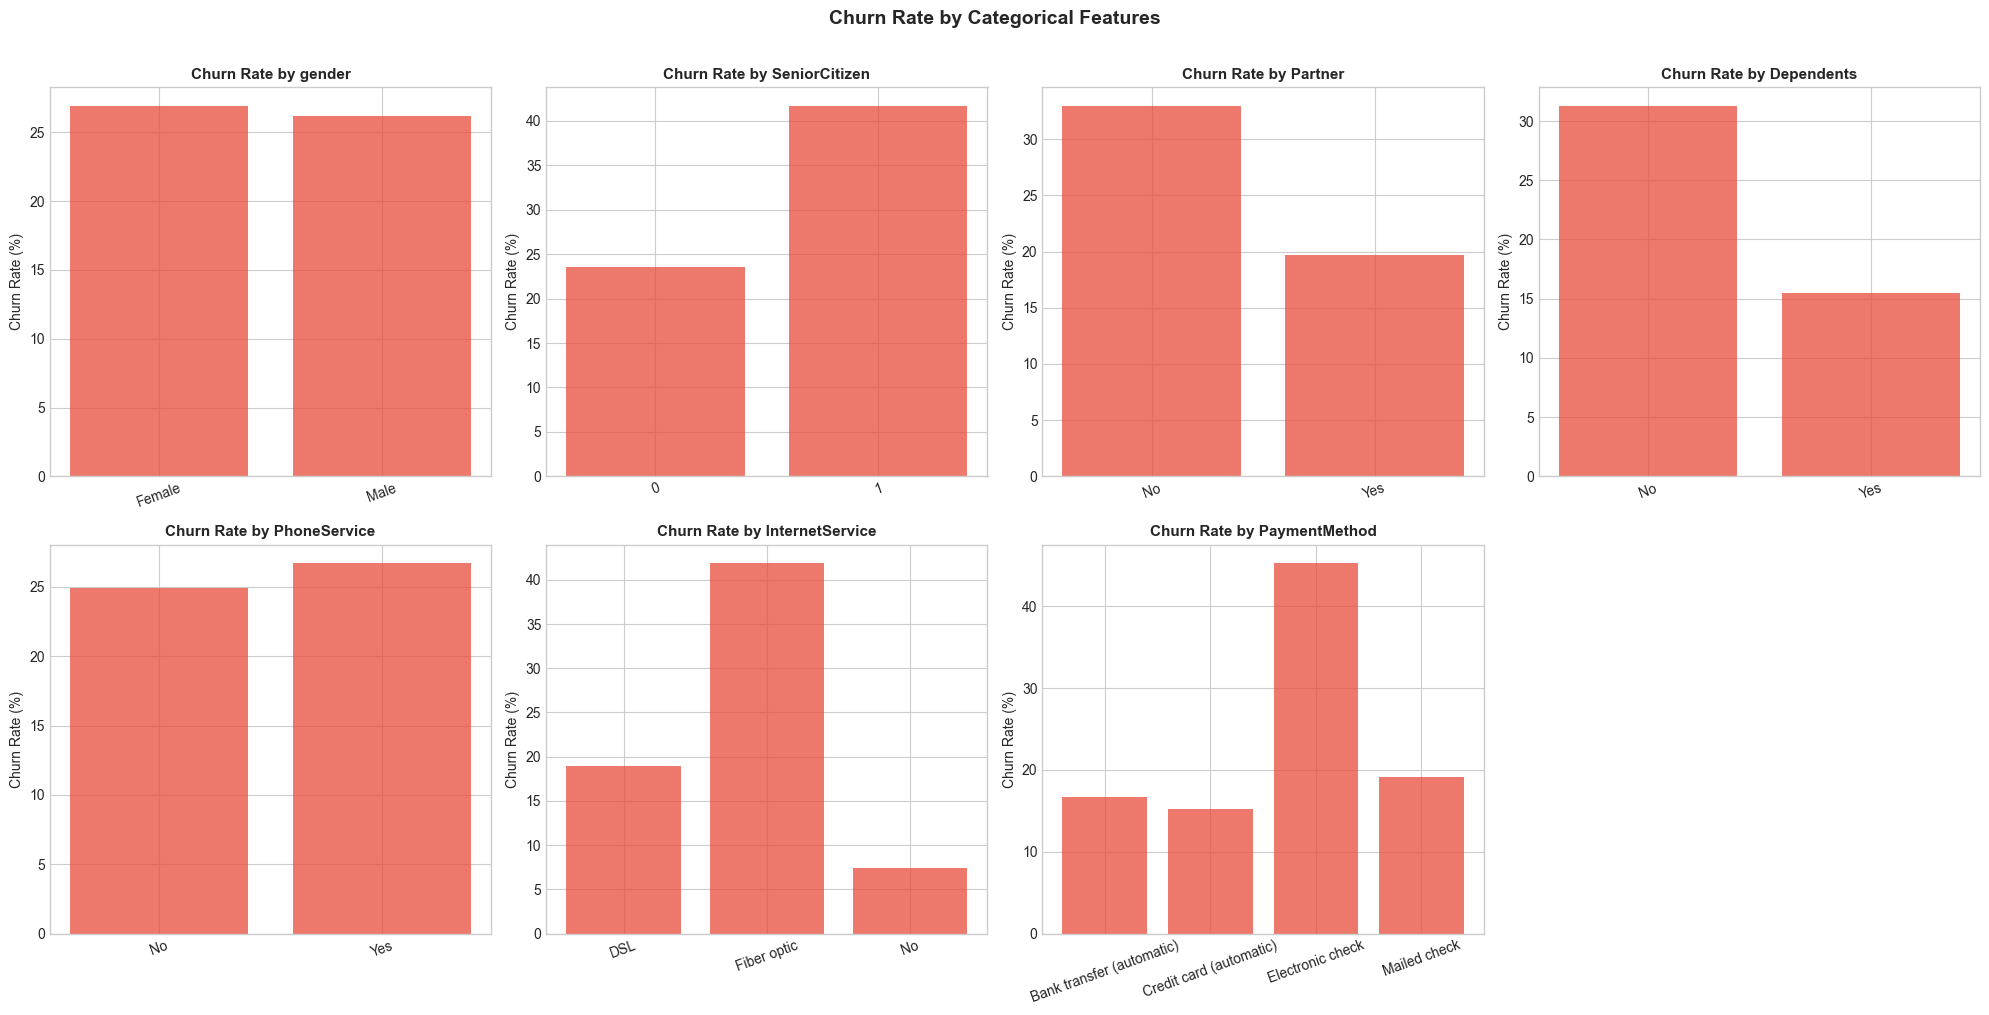

In [11]:
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_by_col = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_by_col.columns = [col, 'Churn Rate (%)']

    axes[i].bar(churn_by_col[col].astype(str), churn_by_col['Churn Rate (%)'],
                color='#e74c3c', alpha=0.75)
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/processed/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

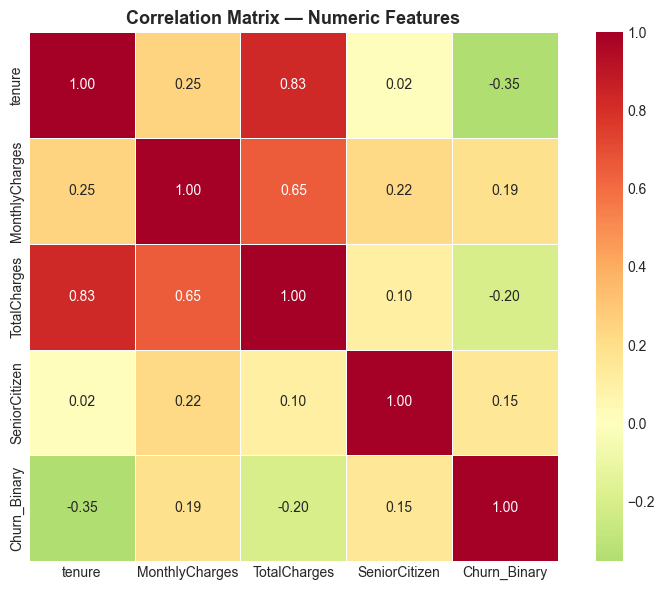

In [12]:
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')
df_temp['Churn_Binary'] = (df_temp['Churn'] == 'Yes').astype(int)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Binary']
corr_matrix = df_temp[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')

print("=" * 55)
print("EDA SUMMARY — TELCO CHURN DATASET")
print("=" * 55)
print(f"Total customers:        {len(df):,}")
print(f"Features:               {df.shape[1]}")
print(f"Churn rate:             {(df['Churn']=='Yes').mean()*100:.1f}%")
print(f"Avg monthly charges:    ${df['MonthlyCharges'].mean():.2f}")
print(f"Avg tenure:             {df['tenure'].mean():.1f} months")
print(f"Month-to-month %:       {(df['Contract']=='Month-to-month').mean()*100:.1f}%")
print(f"TotalCharges nulls:     {df_temp['TotalCharges'].isnull().sum()} (new customers)")
print()
print("TOP CHURN RISK FACTORS OBSERVED:")
print("  1. Month-to-month contract (~43% churn rate)")
print("  2. Fiber optic internet service (~42% churn rate)")
print("  3. Electronic check payment method (~45% churn rate)")
print("  4. Senior citizens (~41% churn rate)")
print("  5. Short tenure — first 5 months highest risk")
print("  6. High monthly charges relative to tenure")

EDA SUMMARY — TELCO CHURN DATASET
Total customers:        7,043
Features:               21
Churn rate:             26.5%
Avg monthly charges:    $64.76
Avg tenure:             32.4 months
Month-to-month %:       55.0%
TotalCharges nulls:     11 (new customers)

TOP CHURN RISK FACTORS OBSERVED:
  1. Month-to-month contract (~43% churn rate)
  2. Fiber optic internet service (~42% churn rate)
  3. Electronic check payment method (~45% churn rate)
  4. Senior citizens (~41% churn rate)
  5. Short tenure — first 5 months highest risk
  6. High monthly charges relative to tenure
